# Cluster (Kmeans, Kmedoids, Agglomerative) Demo

 - Course Title: Problem Solving Using Pattern Recognition
 - Lecturer: Zhengqing Hu
 - Copyright 2026 National University of Singapore
 - Jupyter Notebook v 7.1.2
 - Python 3.12.2 (!python --version)
 - scikit-learn 1.4.2 (!pip show scikit-learn)

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

## Load the dataset

In [9]:
df = pd.read_csv("BirthDeathRates.csv")
cols = list(df) 
data = df.drop(['SN','Country'], axis=1)
data2= data.copy()

In [10]:
df.head()

,SN,Country,Literacy,Baby Mort,Birth Rate,Death Rate
0,1,Argentina,95,25.6,20,9
1,2,Australia,100,7.3,15,8
2,3,Bolivia,78,75.0,34,9
3,4,Cameroon,54,77.0,41,12
4,5,Chile,93,14.6,23,6


In [11]:
print("Summary Statistics:\n")
sumary = data.describe(percentiles=[])
#print(data.info())
print(np.transpose(np.round(sumary)))

Summary Statistics:

            count  mean   std   min   50%    max
Literacy     25.0  73.0  22.0  24.0  78.0  100.0
Baby Mort    25.0  53.0  36.0   7.0  52.0  126.0
Birth Rate   25.0  29.0  11.0  10.0  28.0   46.0
Death Rate   25.0   9.0   4.0   2.0   9.0   19.0


### Check for Outliers & Normality

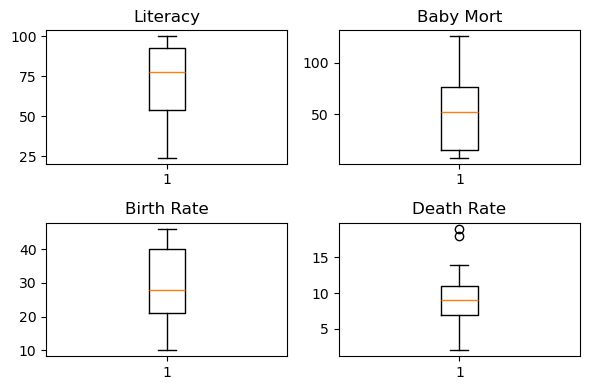

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(6, 4))

for i in range(4):
    ax = axes[i // 2, i % 2]
    ax.boxplot(data.iloc[:, i])
    ax.set_title(data.columns[i])

plt.tight_layout()
plt.show()

 - Some outliers for Death Rate. It is reasonable that some countries have very low birth rates.
 - No servere skews except for baby mortality - But it does reflects reality.

### Standardize the Data

In [13]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
#data_std = StandardScaler().fit_transform(data) 
#data_std = MinMaxScaler().fit_transform(data)
data_std = data

## K-means clustering

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

In [15]:
# kmeans = KMeans(n_clusters=i, init="k-means++", n_init = 10, max_iter= 100)

# The default values are n_init=10 and max_iter=300. 
# This means the initial centroids will be chosen 10 times, 
# and each run will use up to 300 iterations. 
# The best out of those 10 runs will be the final result.
# ‘k-means++’ : selects initial cluster centers 
# in a smart way to speed up convergence.

## Examine the Silhouette plots to find optimal K

Silhouette Visualizer

Silhouette analysis can be used to evaluate the density and separation between clusters. The score is calculated by averaging the silhouette coefficient for each sample, which is computed as the difference between the average intra-cluster distance and the mean nearest-cluster distance for each sample, normalized by the maximum value. This produces a score between -1 and +1, where scores near +1 indicate high separation and scores near -1 indicate that the samples may have been assigned to the wrong cluster.

The SilhouetteVisualizer displays the silhouette coefficient for each sample on a per-cluster basis, allowing users to visualize the density and separation of the clusters. This is particularly useful for determining cluster imbalance or for selecting a value for K
by comparing multiple visualizers.

Reference:
https://vitalflux.com/kmeans-silhouette-score-explained-with-python-example/#google_vignette <br>
code downloaded: **yellowbrick-clustering-evaluation-examples.ipynb**

n_clusters = 2 Average silhouette_score = 0.5581364427996222
n_clusters = 3 Average silhouette_score = 0.5009928524856495
n_clusters = 4 Average silhouette_score = 0.47912606087760806
n_clusters = 5 Average silhouette_score = 0.4477858787711104
n_clusters = 6 Average silhouette_score = 0.43571402309277085
n_clusters = 7 Average silhouette_score = 0.40657679718273704


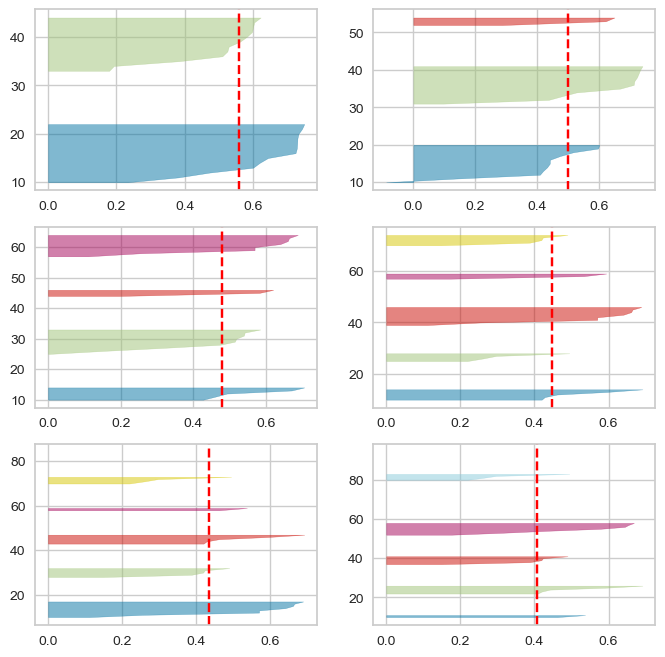

In [16]:
from yellowbrick.cluster import SilhouetteVisualizer, KElbowVisualizer
 
fig, ax = plt.subplots(3, 2, figsize=(8,8))

for i in [2, 3, 4, 5, 6, 7]:
    clusterer = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=42)
    q, mod = divmod(i, 2)
    visualizer = SilhouetteVisualizer(clusterer, colors='yellowbrick', ax=ax[q-1][mod], force_model=True)
    visualizer.fit(data_std) 
    silhouette_avg = silhouette_score(data_std, clusterer.fit_predict(data_std))
    print("n_clusters =", i, "Average silhouette_score =", silhouette_avg,)

From the silhouette scores above, all are above 0.4

## Scree Plot or Elbow Method to select K

**from yellowbrick.cluster import KElbowVisualizer**

By default, the scoring parameter metric is set to *distortion*, which computes the sum of squared distances from each point to its assigned center (WSS). However, two other metrics can also be used with the KElbowVisualizer— *silhouette* and *calinski_harabasz*. <br>
 - silhouette score is the mean silhouette coefficient for all samples
 - calinski_harabasz score computes the ratio of the sum of between-cluster dispersion to the sum of within-cluster dispersion. It evaluates how well clusters are separated from each other in a dataset. The Higher score means that the Clusters are dense and well separated.


The KElbowVisualizer also displays the amount of time to fit the model per K, which can be hidden by setting timings=False

https://www.kaggle.com/code/kautumn06/yellowbrick-clustering-evaluation-examples

### WCSS Plots

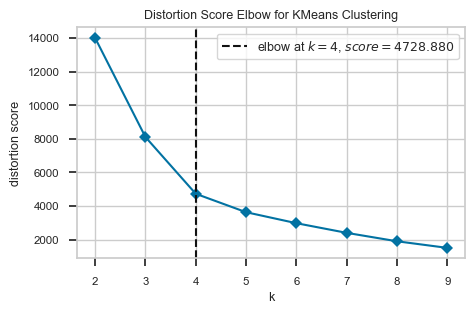

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [17]:
# Set the context for the plot
sns.set_context("notebook", font_scale=0.75)
# Using the Distortion score
clusterer = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=42)
visualizer = KElbowVisualizer(clusterer, k=(2,10), size=(500, 300), timings=False, force_model=True)

visualizer.fit(data_std)    # Fit the data to the visualizer
visualizer.poof()    # Draw/show/poof the data

### Calinski_Harabasz index plots

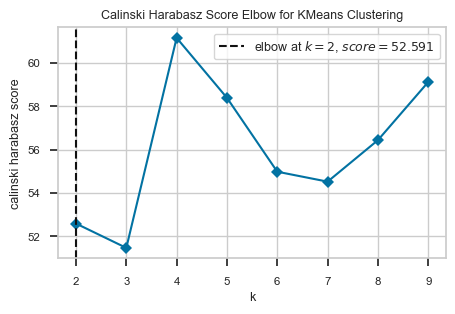

<Axes: title={'center': 'Calinski Harabasz Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='calinski harabasz score'>

In [18]:
# Using the calinski_harabasz
clusterer = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=42)
visualizer = KElbowVisualizer(clusterer, k=(2,10), metric='calinski_harabasz', size=(500, 300), timings=False, force_model=True)
visualizer.fit(data_std)    # Fit the data to the visualizer
visualizer.poof()    # Draw/show/poof the data

It appears that k = 4 is recommended using both Distortion and calinski_harabasz

### Davies-Bouldin Score plot

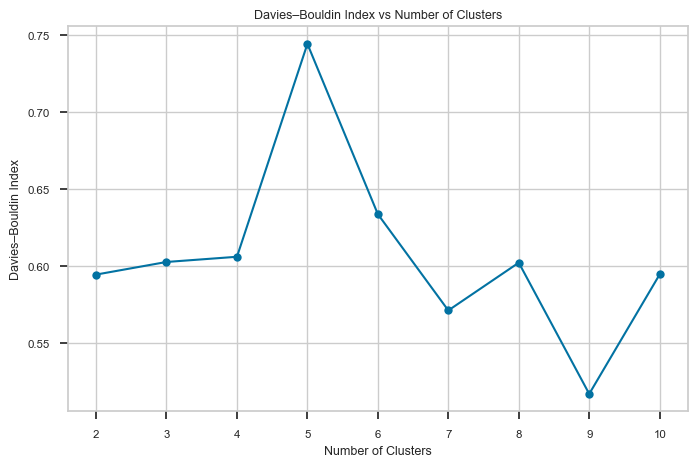

In [19]:
from sklearn.metrics import davies_bouldin_score
# Initialize list to store DBI scores
dbi_scores = []

# Loop over a range of cluster values
for i in range(2, 11):
    clusterer = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=42)
    labels = clusterer.fit_predict(data_std)
    dbi = davies_bouldin_score(data_std, labels)
    dbi_scores.append(dbi)

# Plot the DBI scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), dbi_scores, marker='o')
plt.title('Davies–Bouldin Index vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies–Bouldin Index')
plt.grid(True)
plt.savefig('dbi_vs_clusters.png')
plt.show()

 - **Lower DBI values** indicate better clustering: compact (low intra-cluster distance) and well-separated (high inter-cluster distance)
 - **Higher DBI values** suggest overlapping or poorly defined clusters.

 - The lowest score is with 8 clusters - but this is inappropriate for the WHO business case. While 2,3 and 4 clusters are ok.

In [20]:
# We select K = 4 to be the optimal 
optimal_clusters = 4
kmeans = KMeans(n_clusters= optimal_clusters, init="k-means++", n_init = 10, max_iter= 100, random_state=42)
cluster_labels = kmeans.fit_predict(data_std)

silhouette_avg = silhouette_score(data_std, cluster_labels)

In [21]:
# Lets check the cluster centroids
# You can extract the centroids using the attribute kmeans.cluster_centers_
data['Cluster'] = cluster_labels

temp=data.groupby('Cluster').agg('mean')
temp['Count'] = data.groupby('Cluster')['Cluster'].count()
np.transpose(np.round(temp, decimals =2))

Cluster,0,1,2,3
Literacy,87.2,62.11,33.67,92.62
Baby Mort,44.2,73.54,115.00,11.86
Birth Rate,24.4,36.00,43.67,18.50
Death Rate,6.6,10.78,15.33,7.25
Count,5.0,9.00,3.00,8.00


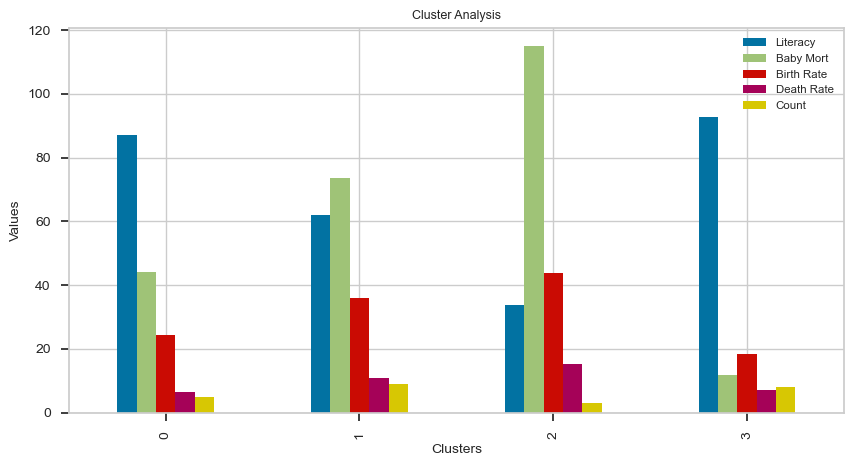

In [22]:
ax = temp.plot(kind='bar', title ="Cluster Analysis", figsize=(10, 5), legend=True, fontsize=10)
ax.set_xlabel("Clusters", fontsize=10)
ax.set_ylabel("Values", fontsize=10)
plt.show()

In [23]:
df['Cluster'] = kmeans.labels_
df.sort_values(by=['Cluster'], inplace=True)
# Filter the DataFrame to include only 'Country' and 'Cluster' columns
filtered_df = df.filter(['Country', 'Cluster'])

# Print the list of countries for each cluster
for cluster in filtered_df['Cluster'].unique():
    print(f"Cluster {cluster}:")
    print(filtered_df[filtered_df['Cluster'] == cluster]['Country'].tolist(),'\n')

Cluster 0:
['Thailand', 'Phillippines', 'China', 'Mexico', 'Vietnam'] 

Cluster 1:
['Indonesia', 'Nigeria', 'Nicaragua', 'Kenya', 'India', 'Zambia', 'Egypt', 'Cameroon', 'Bolivia'] 

Cluster 2:
['Ethiopia', 'Somalia', 'Haiti'] 

Cluster 3:
['Greece', 'Italy', 'Kuwait', 'Costa Rica', 'Chile', 'Australia', 'USA', 'Argentina'] 



## Cluster Interpretation using Boxplots

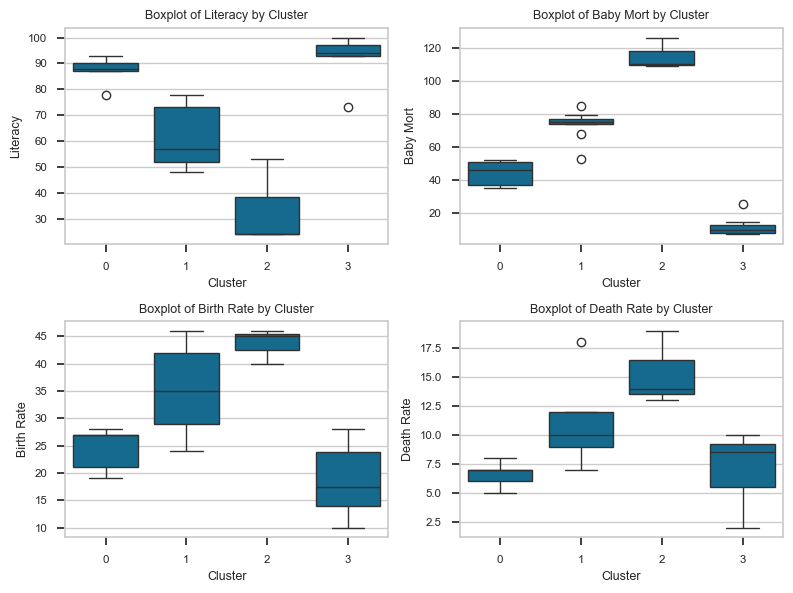

In [24]:
# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# Flatten the axes array for easy iteration
axes_flat = axes.flatten()

# Plot each feature's boxplot in a subplot
for i, feature in enumerate(data.columns[:-1]):  # Exclude the 'Cluster' column
    sns.boxplot(x='Cluster', y=feature, data=data, ax=axes_flat[i])
    axes_flat[i].set_title(f'Boxplot of {feature} by Cluster')

# Adjust the layout so plots don't overlap
plt.tight_layout()

# Display the plot
plt.show()

# KMedoids

A mediod is an exemplar or an actual data point.
"mediod" is the data point that has the least distance to every other point in the cluster.
Therefore you need to precompute the distances between every data point and this will be used as a lookup as the algorithm iterates.
Note that the distance between every data point to every data point is fixed - unlike kmeans where the centroid keeps changing with every iteration.

The `pdist` function computes the pairwise distances between all data points, and `squareform` converts this condensed distance matrix into a square, symmetric matrix. This distance matrix is then used by the k-medoids algorithm to find the optimal medoids and assign points to the nearest medoid.

In [25]:
#!pip install kmedoids

In [27]:
import kmedoids
from scipy.spatial.distance import pdist, squareform

In [28]:
# Read in the dataset
df = pd.read_csv("BirthDeathRates.csv")
cols = list(df) 
data = df.drop(['SN','Country'], axis=1)

In [29]:
# Pre-Compute the distance matrix
distmatrix = squareform(pdist(data, metric='euclidean'))
# Perform k-medoids clustering
c = kmedoids.fasterpam(distmatrix, 4, random_state = 42)
print("Loss is:", c.loss)

Loss is: 318.7715011370578


In k-medoids clustering, the "loss" refers to the total cost or dissimilarity within the clusters. It is calculated as the sum of the distances between each data point and the medoid of its assigned cluster. The goal of the k-medoids algorithm is to minimize this loss, thereby ensuring that the chosen medoids are as representative as possible of the data points in their respective clusters.

In [30]:
#print("Medoids:", c.medoid)
print(c.medoids)

[ 8  3 22 23]


In [31]:
a = []
for m in c.medoids:
#    print("Cluster medoids:", df.iloc[m, df.columns.get_loc('Country')])
    a.append(df.iloc[m, df.columns.get_loc('Country')])
print(a)

['Ethiopia', 'Cameroon', 'USA', 'Vietnam']


In [32]:
df['Cluster'] = c.labels
df.sort_values(by=['Cluster'], inplace=True)
# Filter the DataFrame to include only 'Country' and 'Cluster' columns
filtered_df = df.filter(['Country', 'Cluster'])

# Print the list of countries for each cluster
for cluster in filtered_df['Cluster'].unique():
    print(f"Cluster {cluster}:")
    print(filtered_df[filtered_df['Cluster'] == cluster]['Country'].tolist(),'\n')

Cluster 0:
['Somalia', 'Ethiopia', 'Haiti'] 

Cluster 1:
['Zambia', 'Bolivia', 'Cameroon', 'Nigeria', 'Nicaragua', 'Egypt', 'India', 'Kenya'] 

Cluster 2:
['USA', 'Kuwait', 'Argentina', 'Greece', 'Costa Rica', 'Chile', 'Australia', 'Italy'] 

Cluster 3:
['Vietnam', 'Mexico', 'China', 'Phillippines', 'Thailand', 'Indonesia'] 



In [33]:
# Create a DataFrame to display the medoids
data['Cluster'] = c.labels
#medoids_df = pd.DataFrame(data.iloc[c.medoids], columns=data.columns)
medoids_df = pd.DataFrame(data.iloc[c.medoids], columns=data.columns)
print("Cluster Medoids (Centroids):")
print(medoids_df)

Cluster Medoids (Centroids):
    Literacy  Baby Mort  Birth Rate  Death Rate  Cluster
8         24      110.0          45          14        0
3         54       77.0          41          12        1
22        97        8.1          15           9        2
23        88       46.0          27           8        3


## Choose the optimal number of clusters

 - https://pypi.org/project/kmedoids/
 - kmedoids package includes DynMSC, an algorithm that optimizes the Medoid Silhouette, and chooses the "optimal" number of clusters in a range of kmin..kmax.

In [34]:
from sklearn.metrics.pairwise import euclidean_distances
X = data
diss = euclidean_distances(X)
kmin, kmax = 3, 5
dm = kmedoids.dynmsc(diss, kmax, kmin)
print("Medoid Silhouette over range of k:", dm.losses)
print("Range of k:", dm.rangek)
print("Optimal number of clusters according to the Medoid Silhouette:", dm.bestk)

Medoid Silhouette over range of k: [0.67710627 0.68415046 0.6915963 ]
Range of k: [3 4 5]
Optimal number of clusters according to the Medoid Silhouette: 5


# Agglomerative Clustering

In [35]:
from sklearn.cluster import AgglomerativeClustering

# refer to the link for the parameters:
#       https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html

hclust = AgglomerativeClustering(n_clusters=4)
hclust.fit(data_std)
#hclust.labels_

AgglomerativeClustering(n_clusters=4)

In [36]:
df = data.copy()
df['Cluster'] = hclust.labels_

temp=df.groupby('Cluster').agg('mean')
temp['Count'] = df.groupby('Cluster')['Cluster'].count()
np.transpose(np.round(temp, decimals =2))

Cluster,0,1,2,3
Literacy,62.11,92.29,33.67,88.50
Baby Mort,73.54,9.90,115.00,41.10
Birth Rate,36.00,18.29,43.67,23.67
Death Rate,10.78,7.00,15.33,7.00
Count,9.00,7.00,3.00,6.00
